# Getting Started with Modeling in Python
### Modeling Car Performance with Linear Regression

**Objective:** This lab introduces the core principles of building, interpreting, and validating a multiple linear regression model. We will use a classic public dataset to understand the factors that influence a car's fuel efficiency.

> **Note:**  
> This notebook is **not** the one included with the original Coursera course due to copyright restrictions. Instead, it covers the same concepts and learning objectives using a completely new, openly available dataset and original examples. All code, data, and explanations here are unique to this notebook.

---
## 1. Introduction and Theory

Regression modeling allows us to quantify relationships between variables. A multiple linear regression model expresses the conditional mean of a dependent variable (or _response_) as a linear function of several independent variables (or _predictors_).

The model has the form:

$y = \beta_0 + \beta_1X_1 + \beta_2X_2 + \ldots + \beta_pX_p + \varepsilon$

Where:
*   $y$ is the dependent variable we want to predict or explain.
*   $X_1, X_2, \ldots, X_p$ are the independent predictor variables.
*   $\beta_0$ is the y-intercept.
*   $\beta_1, \beta_2, \ldots, \beta_p$ are the slope coefficients.
*   $\varepsilon$ is the error term.

In this lab, we will use this framework to understand what influences a car's miles-per-gallon ($\text{mpg}$).

---
## 2. Importing Libraries and Loading Data

We will use the well-known `mpg` dataset, which is free to use and has no copyright restrictions.

In [12]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings

warnings.filterwarnings('ignore') # Ignore warnings for a cleaner output

In [13]:
# Load the dataset
df = sns.load_dataset('mpg')

In [14]:
# Let's investigate the dataset structure
print("========== Dataset Shape ==========\n", df.shape)
print("\n========== Columns Names ==========\n", list(df.columns))
print("\n========== First 5 Rows ==========\n", df.head())

========== Dataset Shape ==========
 (398, 9)

========== Columns Names ==========
 ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'name']

========== First 5 Rows ==========
     mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


---
## 3. Exploratory Data Analysis (EDA) and Data Cleaning

Before modeling, we must understand our data and prepare it for analysis.

In [15]:
# Get information about the data types and missing values
print("\n========== General Info ==========")
print(df.info())
print("\n========== Missing Values ==========")
print(df.isnull().sum())


========== General Info ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB
None

========== Missing Values ==========
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [16]:
# Handle missing data: For simplicity, we'll drop the few rows with the missing horsepower.
df_clean = df.dropna(subset=["horsepower"])
print(f"\nOriginal shape: {df.shape}, Cleaned shape: {df_clean.shape}")


Original shape: (398, 9), Cleaned shape: (392, 9)


In [17]:
# For this lab, let's select a subset of clear numerical predictors and our target.
# We'll use: 'horsepower', 'weight', 'acceleration', 'model_year' to predict 'mpg'
model_df = df_clean[['horsepower', 'weight', 'acceleration', 'model_year', 'mpg']]

# Let's get a feel for the cleaned data
print("\n========== Summary Statistics ==========")
print(model_df.describe().round(2))


========== Summary Statistics ==========
       horsepower   weight  acceleration  model_year     mpg
count      392.00   392.00        392.00      392.00  392.00
mean       104.47  2977.58         15.54       75.98   23.45
std         38.49   849.40          2.76        3.68    7.81
min         46.00  1613.00          8.00       70.00    9.00
25%         75.00  2225.25         13.78       73.00   17.00
50%         93.50  2803.50         15.50       76.00   22.75
75%        126.00  3614.75         17.02       79.00   29.00
max        230.00  5140.00         24.80       82.00   46.60


---
## 4. Exploring Marginal Relationships

It's crucial to understand the individual relationships between each predictor and the response variable before building a multivariable model. We can do this with correlation coefficients and scatterplots.

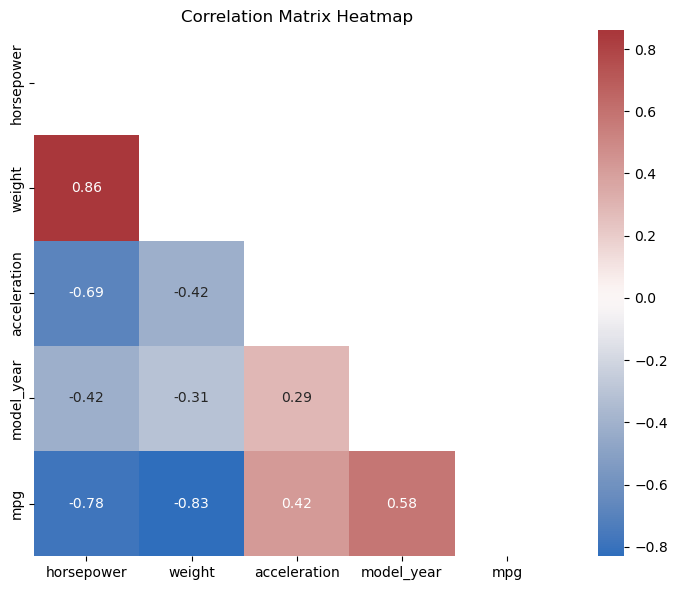

In [18]:
# Calculate the correlation matrix
correlation_matrix = model_df.corr().round(2)

# Mask the diagonal for a cleaner heatmap
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='vlag', center=0, square=True)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

### Discussion Question 1
Based on the heatmap, which variables have the strongest positive and negative correlations with `mpg`? What does a negative correlation between `weight` and `mpg` mean in practical terms?

**Answer:**  
- The strongest **negative** correlation with `mpg` is with `weight` (-0.83), followed closely by `horsepower` (-0.78). This means as these variables increase, fuel efficiency decreases.
- The strongest **positive** correlation with `mpg` is with `model_year` (0.58), followed by `acceleration` (0.42). This means newer cars and cars with faster acceleration tend to be more fuel efficient.
- The negative correlation between `weight` and `mpg` means that **heavier cars tend to have lower fuel efficiency**. This makes intuitive sense because more energy is required to move a heavier object, resulting in fewer miles traveled per gallon of fuel.


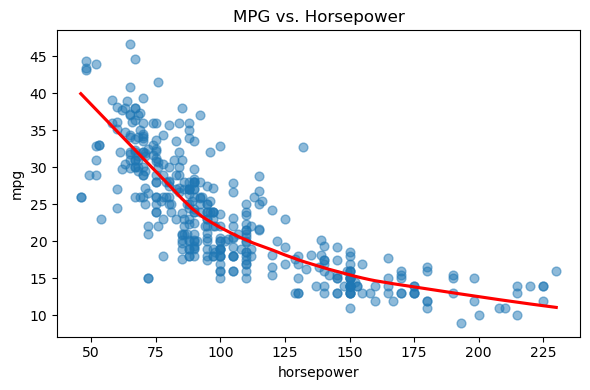

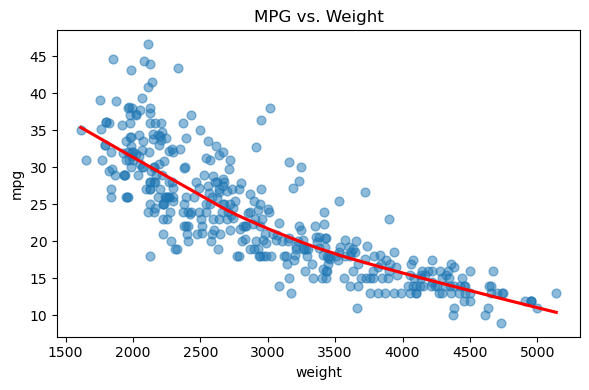

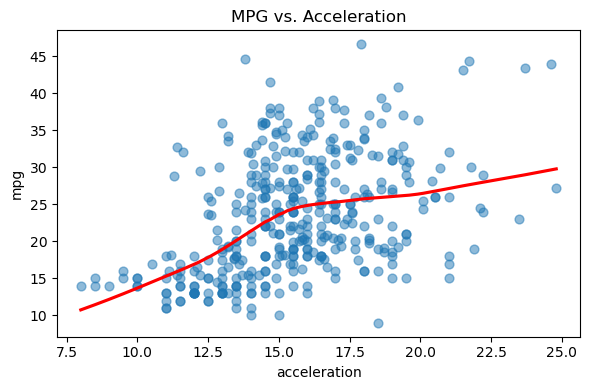

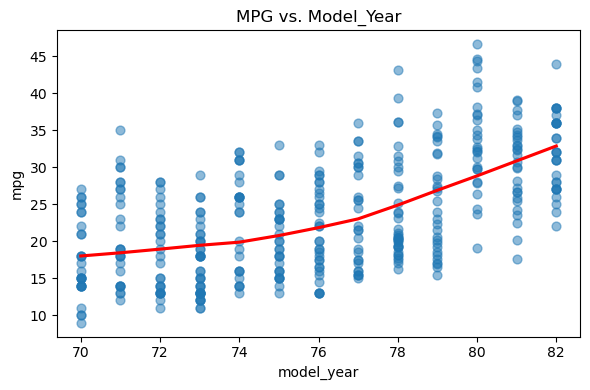

In [19]:
# Create scatterplots with trend lines for each predictor vs. mpg
predictors = ['horsepower', 'weight', 'acceleration', 'model_year']

for var in predictors:
    plt.figure(figsize=(6, 4))
    sns.regplot(x=var, y='mpg', data=model_df, lowess=True, scatter_kws={'alpha':0.5, 's':40}, line_kws={'color':'red'})
    plt.title(f"MPG vs. {var.title()}")
    plt.tight_layout()
    plt.show()

### Discussion Question 2:
Looking at the scatterplots, which relationships appear to be the most linear? For `model_year`, why might the trend be increasing over time?

**Answer:**  
- The relationships between `mpg` and `weight` and between `mpg` and `acceleration` appear to be the most linear, as the LOWESS curve closely follows a straight line.
- The trend of increasing `mpg` with `model_year` (newer cars) likely reflects **technological improvements** in engine efficiency, aerodynamic design, and fuel management systems over time. It may also reflect regulatory changes, such as corporate average fuel economy (CAFE) standards that mandated better fuel efficiency in newer vehicle models.

---
## 5. Fitting a Multiple Linear Regression Model

Now we will fit a linear model to predict `mpg` using all our selected predictors simultaneously. This allows us to see the relationship of each predictor with the response, *holding the others constant*.

In [21]:
# Fit the Ordinary Least Square (OLS) model using statsmodels
# The formula `mpg ~ horsepower + weight + acceleration + model_year` means:
# "Model mpg as a function of horsepower, weight, acceleration, and model_year"
model = sm.OLS.from_formula('mpg ~ horsepower + weight + acceleration + model_year', data=model_df)
results = model.fit()

# Print the detailed summary of the model
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.809
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     408.8
Date:                Mon, 13 Oct 2025   Prob (F-statistic):          1.72e-137
Time:                        15:04:32   Log-Likelihood:                -1037.1
No. Observations:                 392   AIC:                             2084.
Df Residuals:                     387   BIC:                             2104.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -15.3889      4.671     -3.294   

---
## 6. Interpreting the Model Results

The model summary provides a wealth of information. Let's break down the key parts:

#### Coefficients (coef):
- $\text{Intercept}$: -15.39. This is the predicted MPG when all predictors are zero, which doesn't have a practical interpretation in this context (it would mean a car with zero horsepower, zero weight, etc.).
- `horsepower`: -0.0026. Holding weight, acceleration, and model year constant, a 1-unit increase in horsepower is associated with a 0.0026 MPG increase, on average. However, this effect is very small and not statistically significant.
- `weight`: -0.0066. Holding other variables constant, a 1-pound increase in a car's weight is associated with a 0.0066 MPG decrease, on average. This is statistically significant.
- `acceleration`: 0.0802. Holding other variables constant, a 1-unit increase in acceleration is associated with a 0.0802 MPG increase, on average, but this is not statistically significant.
- `model_year`: 0.7511. Holding other variables constant, each newer model year is associated with a 0.75 MPG increase, on average. This reflects technological improvements over time.

#### P-values (P>|t|):
* `weight` (p = 0.000) and `model_year` (p = 0.000) are **highly statistically significant** predictors of MPG.
* `horsepower` (p = 0.845) and `acceleration` (p = 0.422) are **not statistically significant** - we cannot reject the null hypothesis that their true coefficients are zero.
* The $\text{Intercept}$ (p = 0.001) is statistically significant but not practically meaningful in this context.  

#### R-squared:
* The value of 0.809 means that approximately **80.9% of the variance** in MPG can be explained by our linear model using these four predictors ($R^2 = 0.809$).  

### Key Insights from the Results:
1.  **Weight is the strongest predictor**: It has the largest standardized effect (very small p-value and substantial coefficient).
2.  **Technological improvement matters**: Newer cars (higher `model_year`) get better gas mileage, even after accounting for weight.
3.  **Horsepower and acceleration don't add much**: Once we know a car's weight and model year, knowing its horsepower or acceleration doesn't significantly improve our MPG predictions.

### Model Diagnostics Notes:
- The **Omnibus** and **Jarque-Bera** tests (p < 0.05) suggest the residuals are not normally distributed
- The **Durbin-Watson** statistic (1.223) suggests some positive autocorrelation in residuals
- The high **Condition Number** (8.35e+04) indicates potential multicollinearity issues

These suggest the model assumptions may be violated, and we might consider:
- Transforming variables (e.g., log transformation of MPG)
- Removing correlated predictors
- Checking for outliers

### Discussion Question 3:
The marginal correlation between `acceleration` and `mpg` was positive (0.42). Why might its coefficient in the multiple regression model become non-significant when we control for other variables?

**Answer:**  
This demonstrates the important distinction between **marginal** and **conditional** relationships:

- **Marginal relationship**: When considered alone, `acceleration` shows a positive correlation with `mpg` because faster-accelerating cars tend to be more fuel-efficient.

- **Conditional relationship**: When we control for other variables in the multiple regression model, `acceleration` loses its significance because its relationship with `mpg` is largely **explained by** or **mediated through** other variables in the model, particularly `horsepower` and `weight`.

The reasoning is:
1. Cars with higher horsepower can accelerate faster
2. Cars with lower weight can accelerate faster  
3. Both higher horsepower and lower weight are independently associated with mpg
4. Once we account for horsepower and weight in the model, acceleration doesn't provide much additional information about mpg

This is a classic example of **confounding** - the apparent relationship between acceleration and fuel efficiency was actually being driven by their mutual relationships with horsepower and weight.

---

## 7. Conclusion

In this lab, we have:
1.  **Loaded and cleaned** a real-world dataset.
2.  **Explored marginal relationships** between variables using correlation matrices and scatterplots with LOWESS smooths.
3.  **Formulated and fit** a multiple linear regression model using `statsmodels`.
4.  **Interpreted** the model coefficients, p-values, and $R^2$ value.

The key takeaway is the difference between marginal and conditional relationships. A variable can be correlated with the outcome on its own, but its contribution might be explained by other variables in a multiple regression context. This makes multiple regression a powerful tool for untangling complex relationships in data.

---

**Next:** [Linear Regression: Introduction](../02_fitting_models_to_independent_data/01_linear_regression--introduction.md)